# The CHSH Game: Proving Quantum Entanglement
This notebook simulates the CHSH nonlocal game to mathematically demonstrate the difference between classical correlation and quantum entanglement.

The winning condition for Alice and Bob is: $a \oplus b = x \land y$
* **Classical Limit:** 75% win rate.
* **Quantum Limit (Tsirelson's Bound):** ~85.4% win rate using an entangled $|\Phi^+\rangle$ state and rotated measurement bases.

In [6]:
# Install required libraries
!pip install qiskit qiskit-aer matplotlib

  Using cached qiskit-2.4.1-cp310-abi3-manylinux_2_28_x86_64.whl.metadata (12 kB)
  Using cached qiskit_aer-0.17.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
Using cached qiskit-2.4.1-cp310-abi3-manylinux_2_28_x86_64.whl (9.3 MB)
Using cached qiskit_aer-0.17.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.4 MB)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

## 1. The Classical Strategy
In a purely classical universe, the absolute best strategy Alice and Bob can use is to agree beforehand to always output `0`, regardless of the question they receive. This deterministic approach mathematically maxes out at a 75% win rate.

In [8]:
def play_coursework_classical(num_games=10000):
    """
    Simulates the optimal classical strategy.
    Alice and Bob always output 0.
    """
    wins = 0
    for _ in range(num_games):
        # Referee uniformly distributes questions
        x = np.random.randint(0, 2)
        y = np.random.randint(0, 2)

        # Classical pre-agreed strategy
        a = 0
        b = 0

        # Evaluate win condition: a ⊕ b = x ∧ y
        if (a ^ b) == (x & y):
            wins += 1

    return wins / num_games

## 2. The Quantum Strategy
By sharing an entangled qubit pair ($|\Phi^+\rangle$) and measuring at specific rotational angles derived from $U_\theta = R_y(-2\theta)$, Alice and Bob can exploit quantum interference to break the classical ceiling.

In [9]:
def play_coursework_chsh(num_games=10000):
    """
    Simulates the quantum strategy using Qiskit.
    Applies precise geometric angles mapped directly from the lesson.
    """
    simulator = AerSimulator()
    wins = 0

    for _ in range(num_games):
        x = np.random.randint(0, 2)
        y = np.random.randint(0, 2)

        qc = QuantumCircuit(2, 2)

        # Create the entangled e-bit |Φ+⟩
        qc.h(0)
        qc.cx(0, 1)

        # Alice's actions (Qubit 0)
        if x == 0:
            alpha = 0
            qc.ry(-2 * alpha, 0)
        else:
            alpha = np.pi / 4
            qc.ry(-2 * alpha, 0)

        # Bob's actions (Qubit 1)
        if y == 0:
            beta = np.pi / 8
            qc.ry(-2 * beta, 1)
        else:
            beta = -np.pi / 8
            qc.ry(-2 * beta, 1)

        # Measure both qubits
        qc.measure([0, 1], [0, 1])

        # Execute and extract results
        result = simulator.run(qc, shots=1, memory=True).result()
        measured_bits = result.get_memory()[0]

        # Qiskit orders classical bits as 'b a' (Qubit 1, Qubit 0)
        b = int(measured_bits[0])
        a = int(measured_bits[1])

        # Evaluate win condition
        if (a ^ b) == (x & y):
            wins += 1

    return wins / num_games

## 3. Execution & Visualization
We will run 10,000 games for both strategies to ensure high statistical accuracy, then plot the results against their theoretical mathematical boundaries.

In [10]:
games = 10000
classical_win_rate = play_coursework_classical(games)
quantum_win_rate = play_coursework_chsh(games)

# Print raw scores
print(f"Classical Win Rate: {classical_win_rate * 100:.2f}%")
print(f"Quantum Win Rate:   {quantum_win_rate * 100:.2f}%")

Classical Win Rate: 74.27%
Quantum Win Rate:   85.39%


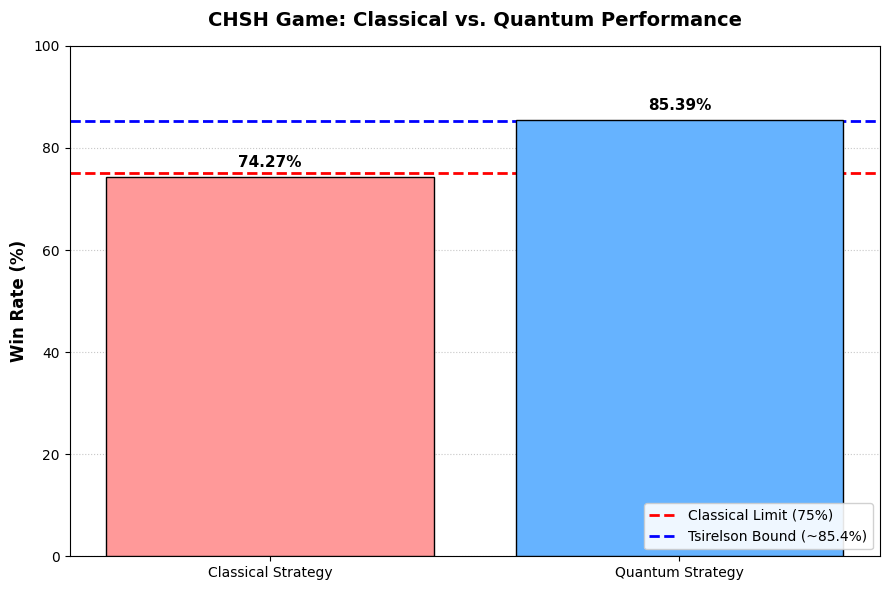

In [11]:
# visualization
strategies = ['Classical Strategy', 'Quantum Strategy']
win_rates = [classical_win_rate * 100, quantum_win_rate * 100]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(strategies, win_rates, color=['#ff9999', '#66b3ff'], edgecolor='black', zorder=3)

# Add horizontal threshold lines for mathematical limits
ax.axhline(y=75.0, color='red', linestyle='--', linewidth=2, zorder=2, label='Classical Limit (75%)')
ax.axhline(y=85.35, color='blue', linestyle='--', linewidth=2, zorder=2, label='Tsirelson Bound (~85.4%)')

ax.set_ylim(0, 100)
ax.set_ylabel('Win Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('CHSH Game: Classical vs. Quantum Performance', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()